In [ ]:
import shap
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score, train_test_split

import lightgbm as lgb

import sys
sys.path.append('..')
from settings import DATA_DIR, TARGET_COLUMN, POST_CAMPAIGN_FEATURES, LGBM_PARAMS

/Users/anubhavbhardwaj/profitable-customer-groups/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [2]:
df = pd.read_csv(DATA_DIR / "customerGroups.csv")
df.shape

(6620, 71)

## Prepare Model Features and Training Data

In [3]:
X = df.drop(columns=[TARGET_COLUMN] + POST_CAMPAIGN_FEATURES)
y = df[TARGET_COLUMN]

In [4]:
y.value_counts()

target
1    3076
2    1877
0    1667
Name: count, dtype: int64

In [5]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(5296, 67) (5296,)
(1324, 67) (1324,)


# Cross Validation

In [7]:
cv_model = lgb.LGBMClassifier(**LGBM_PARAMS)
scores = cross_val_score(cv_model, X, y, 
                         cv=5, scoring='f1_macro', 
                         n_jobs=-1)

In [8]:
scores

array([0.51189579, 0.47519296, 0.52308955, 0.51952175, 0.49983085])

## Training final model

In [9]:
model = lgb.LGBMClassifier(**LGBM_PARAMS)
model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,25
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.1
,min_child_weight,0.001
,min_child_samples,80


In [11]:
y_pred_test = model.predict(X_test)
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_test,
    target_names=['Neither (0)', 'Group 1 (1)', 'Group 2 (2)']
))


Classification Report:
              precision    recall  f1-score   support

 Neither (0)       0.33      0.28      0.30       333
 Group 1 (1)       0.65      0.70      0.67       615
 Group 2 (2)       0.56      0.56      0.56       376

    accuracy                           0.55      1324
   macro avg       0.51      0.51      0.51      1324
weighted avg       0.54      0.55      0.55      1324



# Feature Importance using SHAP

In [14]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

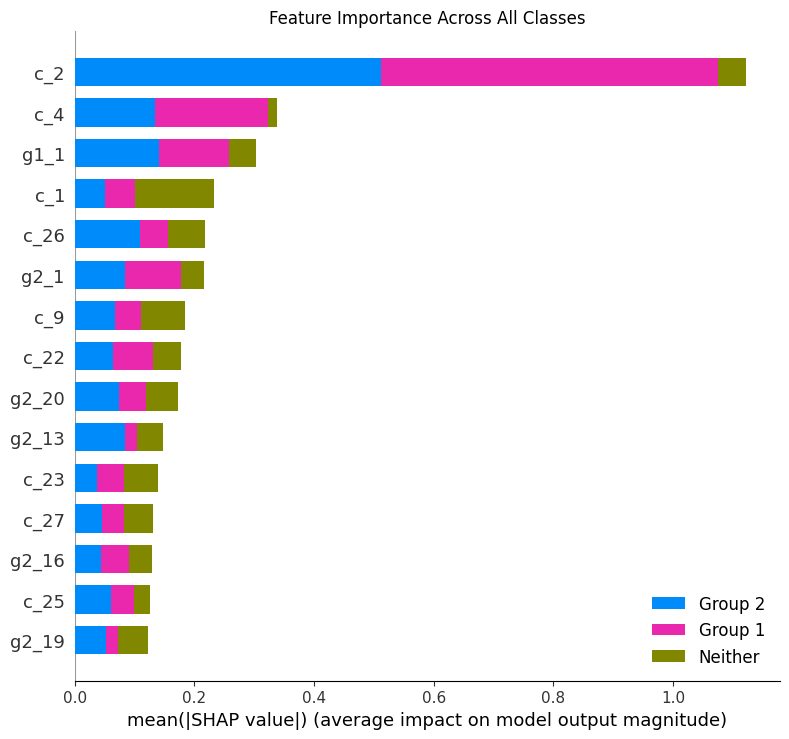

In [15]:
shap.summary_plot(
    [shap_values[:, :, 0],   # Neither first
     shap_values[:, :, 1],   # Group 1 second  
     shap_values[:, :, 2]],  # Group 2 third
    X_test,
    plot_type="bar",
    class_names=["Neither", "Group 1", "Group 2"],
    max_display=15,
    show=False
)
plt.title("Feature Importance Across All Classes")
plt.tight_layout()
plt.savefig('../notebooks/shap_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()